In [2]:
import pandas as pd
import numpy as np
# employee = pd.read_csv("../data/employees.csv")
# expanded = pd.concat([employee]*70,ignore_index = True)
# print(len(expanded))
# expanded['EmpID']=range(1,len(expanded)+1)
# expanded['Age']=np.random.randint(20,46,len(expanded))
# expanded['DepartmentID']=np.random.randint(1,7,len(expanded))
# expanded['Experience']=np.random.randint(1,16,len(expanded))
#print(expanded.head(20))
# expanded.to_csv('../data/employees.csv',index = False)

In [ ]:
# import numpy as np
# expanded= pd.read_csv('../data/employees.csv')
# expanded.head(20)
# department = [1,2,3,4,5,6]
# expanded['DepartmentID'] = np.random.choice(department,size = len(expanded))
# expanded.head(20)
# expanded.to_csv('../data/employees.csv')

In [ ]:
pd.read_csv('../data/employees.csv').head()



In [13]:
expanded = pd.read_csv('../data/departments.csv')
expanded.shape

(6, 3)

In [14]:
data = pd.read_csv('../data/performance.csv')
data.shape

(1050, 4)

In [15]:
#df = pd.read_csv('../data/employees.csv')
df.isna().sum()
avg = round(df['Salary'].mean(),1)
print(avg)
#df.shape
#df['Salary'] = df['Salary'].fillna(avg)
#df['Salary'] = df['Salary'].replace(0,avg)
#df['Region'] = (df['Region']).str.title()
#df.to_csv('../data/employees.csv',index = False)

71314.3


In [17]:
employee = pd.read_csv('../data/employees.csv')
department = pd.read_csv('../data/departments.csv')
perform = pd.read_csv('../data/performance.csv')
data = employee.merge(perform,on = 'EmpID')
data = data.merge(department, on = 'DepartmentID')


data.shape
#data.head()
#data.info()

(1050, 13)

# START OF THE ANALYSIS



In [21]:
# Employee per department

emp_per_dpt = data.groupby('DepartmentName')['EmpID'].size()
print(emp_per_dpt)
data['DepartmentName'].value_counts()

DepartmentName
Finance       173
HR            184
IT            173
Marketing     178
Operations    165
Sales         177
Name: EmpID, dtype: int64


DepartmentName
HR            184
Marketing     178
Sales         177
IT            173
Finance       173
Operations    165
Name: count, dtype: int64

In [22]:
# Gender Distribution

data.groupby('Gender')['EmpID'].size()

Gender
Female    490
Male      560
Name: EmpID, dtype: int64

In [23]:
# Average salary per department

salary_dis = round(data.groupby('DepartmentName')['Salary'].mean(),2)

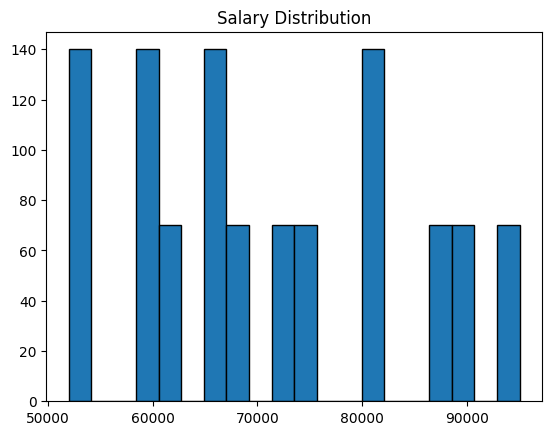

In [24]:
import matplotlib.pyplot as plt
plt.hist(data['Salary'],bins = 20,edgecolor = 'black')
plt.title('Salary Distribution')
plt.show()

# Performance vs Experience

round(data.groupby('Experience')['Rating'].mean(),1)

In [20]:
# Project completed by department

data.groupby('DepartmentName')['Projects'].agg(['sum','mean'])

,sum,mean
DepartmentName,,
Finance,685,3.959538
HR,745,4.048913
IT,695,4.017341
Marketing,730,4.101124
Operations,645,3.909091
Sales,752,4.248588


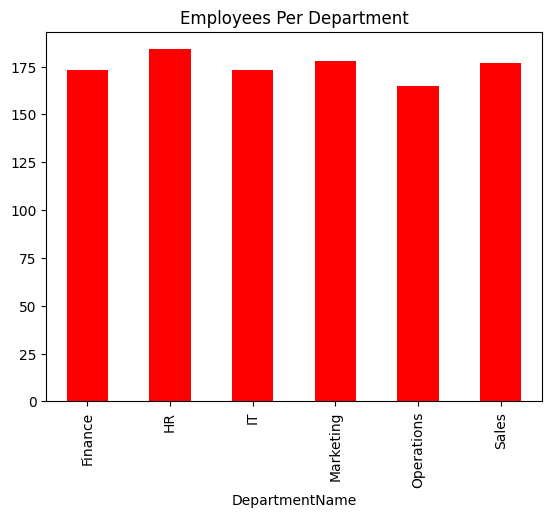

In [25]:
# Visulalization of employee per department
emp_per_dpt = data.groupby('DepartmentName')['EmpID'].size()
emp_per_dpt.plot(kind='bar',color='red')
plt.title('Employees Per Department')
plt.show()

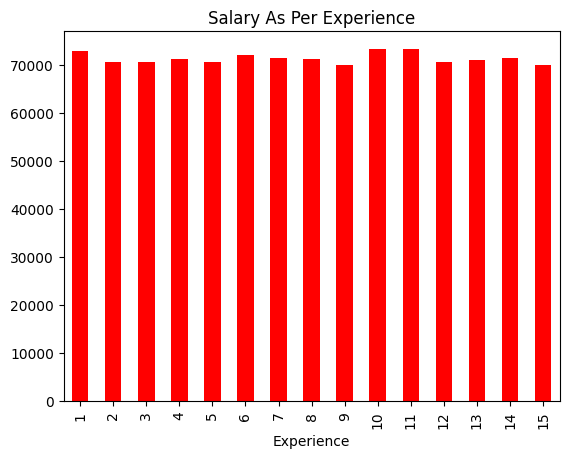

In [26]:
# Salary vs Experience
data.groupby('Experience')['Salary'].mean().plot(kind='bar', color = 'red')
plt.title('Salary As Per Experience')
plt.show()

data.groupby('OvertimeHours')['Rating'].mean().plot(kind='bar', color = 'red')
plt.title('Rating vs Overtime Hours')
plt.show

#department salary cost

data.groupby('DepartmentName')['Salary'].sum().plot(kind = 'bar')
plt.title('Total Salary Cost')
plt.show()

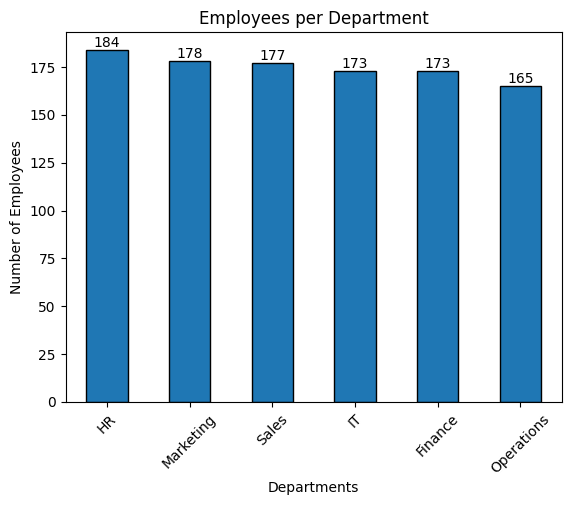

In [39]:
# Find the total employees per department 
#used to find whether there is uneven distribution of workfroce between the departments or not and which department has highest and lowest no of employees
import matplotlib.pyplot as plt
emp_per_dept=data['DepartmentName'].value_counts().plot(kind='bar',edgecolor = 'black')
plt.title('Employees per Department')
plt.ylabel('Number of Employees')
plt.xlabel('Departments')
plt.bar_label(emp_per_dept.containers[0])
plt.xticks(rotation = 45)
plt.show()

[Text(0, 2, '70686'),
 Text(0, 2, '72542'),
 Text(0, 2, '70789'),
 Text(0, 2, '70595'),
 Text(0, 2, '72033'),
 Text(0, 2, '71255')]

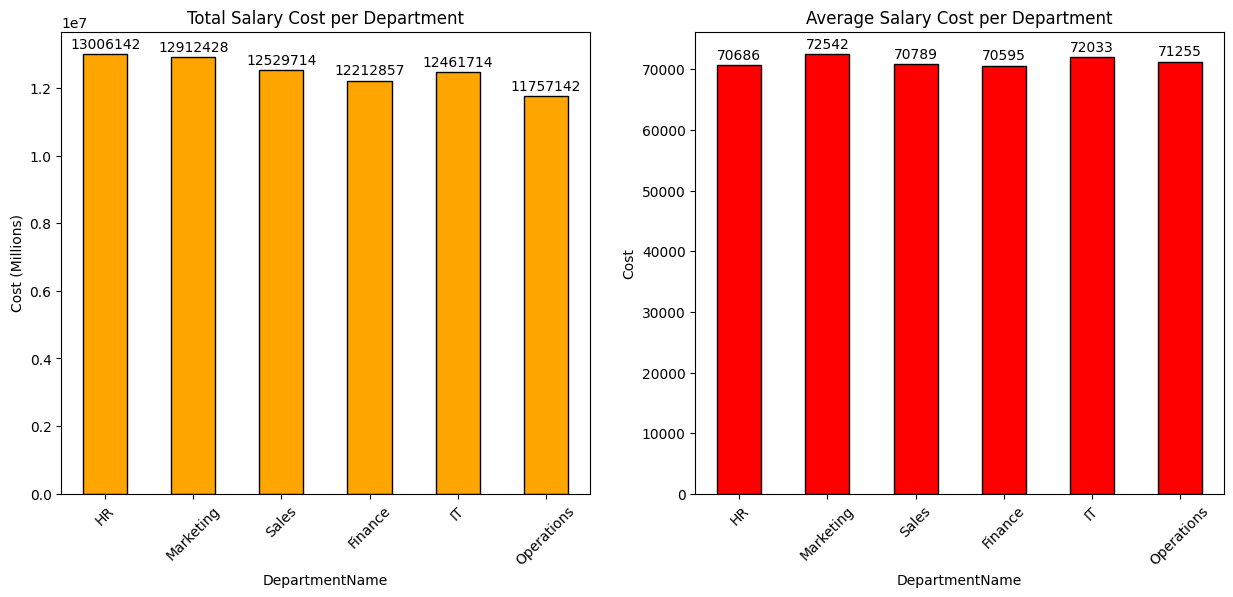

In [59]:
# Salary Cost Analysis

total_salary_cost=data.groupby('DepartmentName')['Salary'].agg(Total_salary = 'sum',Average_salary = 'mean',Total_emp = 'count').round(2).sort_values('Total_emp',ascending=False)
fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,6))
total_salary_cost['Total_salary'].plot(kind='bar',ax = ax1,edgecolor = 'black',color='orange',rot=45)
ax1.set_title('Total Salary Cost per Department')
ax1.set_ylabel('Cost (Millions)')
ax1.bar_label(ax1.containers[0],padding=2,fmt='%.0f')

total_salary_cost['Average_salary'].plot(kind = 'bar',edgecolor='black',color='red',rot=45)
ax2.set_title('Average Salary Cost per Department')
ax2.set_ylabel('Cost')
ax2.bar_label(ax2.containers[0],padding=2,fmt='%.0f')

In [25]:
# Employee Performance Analysis

# data.sort_values('Rating',ascending=False)
performance = data.loc[data['Rating'] == data['Rating'].max()]
performance.groupby('DepartmentName')['EmpID'].count()

DepartmentName
Finance       51
HR            64
IT            59
Marketing     69
Operations    60
Sales         55
Name: EmpID, dtype: int64

In [ ]:
# Department Productivity

data.groupby('DepartmentName')['Projects'].agg(Total = 'sum', Average = 'mean').round(2).sort_values('Total',ascending=False)

,Total,Average
DepartmentName,,
Sales,752,4.25
HR,745,4.05
Marketing,730,4.10
IT,695,4.02
Finance,685,3.96
Operations,645,3.91


Text(0, 0.5, 'Rating')

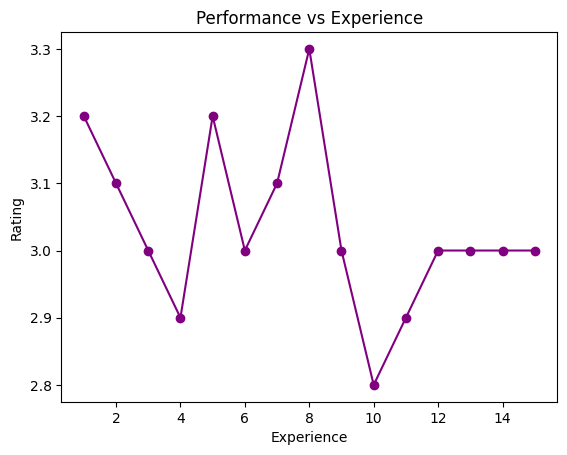

In [72]:
# Experience vs Performance

ax=data.groupby('Experience')['Rating'].mean().round(1).plot(kind='line',marker='o',color='purple')
plt.title('Performance vs Experience')
plt.ylabel('Rating')

                Total_projects  Avg_projects  Performance  Productivity
DepartmentName                                                         
Finance                    685           4.0          2.9         11.60
HR                         745           4.0          3.1         12.40
IT                         695           4.0          3.0         12.00
Marketing                  730           4.1          3.1         12.71
Operations                 645           3.9          3.0         11.70
Sales                      752           4.2          3.0         12.60


[Text(0, 2, '4'),
 Text(0, 2, '4'),
 Text(0, 2, '4'),
 Text(0, 2, '4.1'),
 Text(0, 2, '3.9'),
 Text(0, 2, '4.2')]

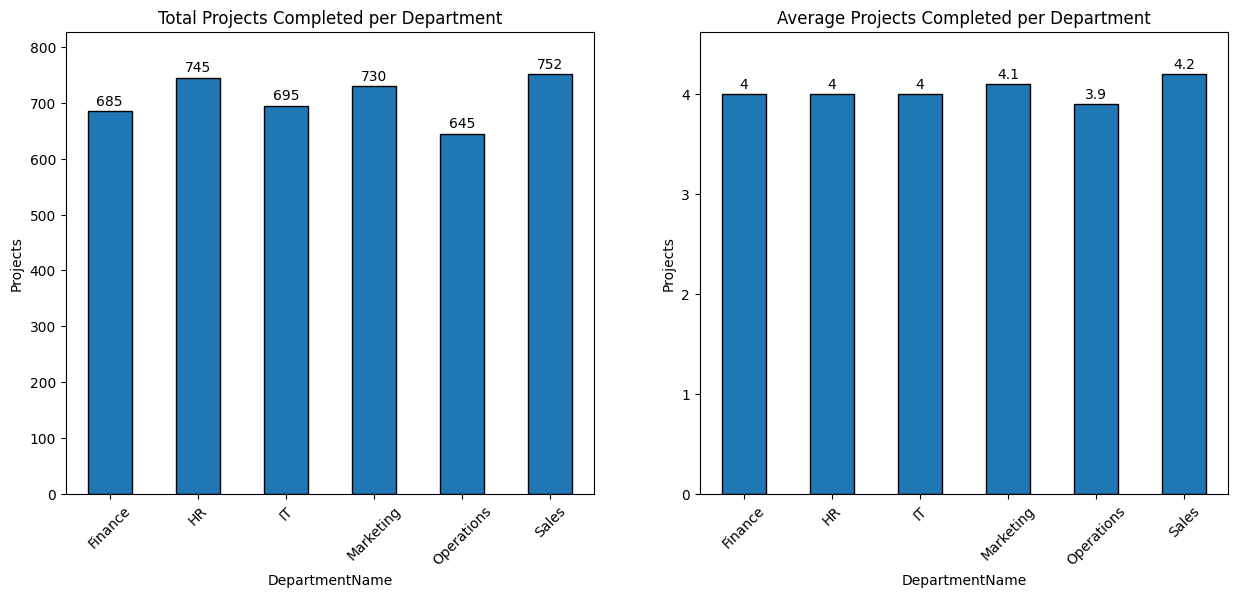

In [33]:
# Performance and Projects

Emp_performance = data.groupby('DepartmentName').agg(Total_projects=('Projects','sum'),Avg_projects=('Projects','mean'),Performance=('Rating','mean')).round(1)
Emp_performance['Productivity'] = Emp_performance['Avg_projects']*Emp_performance['Performance']
print(Emp_performance)
fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,6))
ax1=Emp_performance['Total_projects'].plot(kind='bar',ax = ax1,edgecolor = 'black',rot=45)
ax1.set_title('Total Projects Completed per Department')
ax1.set_ylabel('Projects')
ax1.margins(y=0.1)
ax1.bar_label(ax1.containers[0],padding=2)
ax2 = Emp_performance['Avg_projects'].plot(kind='bar',ax = ax2,edgecolor='black',rot=45)
plt.title('Average Projects Completed per Department')
plt.ylabel('Projects')
ax2.margins(y=0.1)
plt.bar_label(ax2.containers[0],padding=2)